In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


In [3]:
# Carregar dados
df = pd.read_csv('../data/raw/cs-training.csv')

# Limpar
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f"📊 Dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"🎯 Taxa de Inadimplência: {df['SeriousDlqin2yrs'].mean():.2%}")
print(f"❌ Inadimplentes: {df['SeriousDlqin2yrs'].sum():,}")
print(f"✅ Adimplentes: {(df['SeriousDlqin2yrs']==0).sum():,}")

df.head()

📊 Dataset: 150,000 linhas x 11 colunas
🎯 Taxa de Inadimplência: 6.68%
❌ Inadimplentes: 10,026
✅ Adimplentes: 139,974


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Renomear para português
df_pt = df.rename(columns={
    'SeriousDlqin2yrs': 'inadimplente',
    'RevolvingUtilizationOfUnsecuredLines': 'utilizacao_credito',
    'age': 'idade',
    'NumberOfTime30-59DaysPastDueNotWorse': 'atrasos_30_59d',
    'DebtRatio': 'razao_divida',
    'MonthlyIncome': 'renda_mensal',
    'NumberOfOpenCreditLinesAndLoans': 'linhas_credito_abertas',
    'NumberOfTimes90DaysLate': 'atrasos_90d',
    'NumberRealEstateLoansOrLines': 'emprestimos_imoveis',
    'NumberOfTime60-89DaysPastDueNotWorse': 'atrasos_60_89d',
    'NumberOfDependents': 'dependentes'
})

print("✅ Colunas renomeadas!")
print("\nColunas:", df_pt.columns.tolist())

✅ Colunas renomeadas!

Colunas: ['inadimplente', 'utilizacao_credito', 'idade', 'atrasos_30_59d', 'razao_divida', 'renda_mensal', 'linhas_credito_abertas', 'atrasos_90d', 'emprestimos_imoveis', 'atrasos_60_89d', 'dependentes']


In [5]:
df_pt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   inadimplente            150000 non-null  int64  
 1   utilizacao_credito      150000 non-null  float64
 2   idade                   150000 non-null  int64  
 3   atrasos_30_59d          150000 non-null  int64  
 4   razao_divida            150000 non-null  float64
 5   renda_mensal            120269 non-null  float64
 6   linhas_credito_abertas  150000 non-null  int64  
 7   atrasos_90d             150000 non-null  int64  
 8   emprestimos_imoveis     150000 non-null  int64  
 9   atrasos_60_89d          150000 non-null  int64  
 10  dependentes             146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [6]:
df_pt.describe()

,inadimplente,utilizacao_credito,idade,atrasos_30_59d,razao_divida,renda_mensal,linhas_credito_abertas,atrasos_90d,emprestimos_imoveis,atrasos_60_89d,dependentes
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


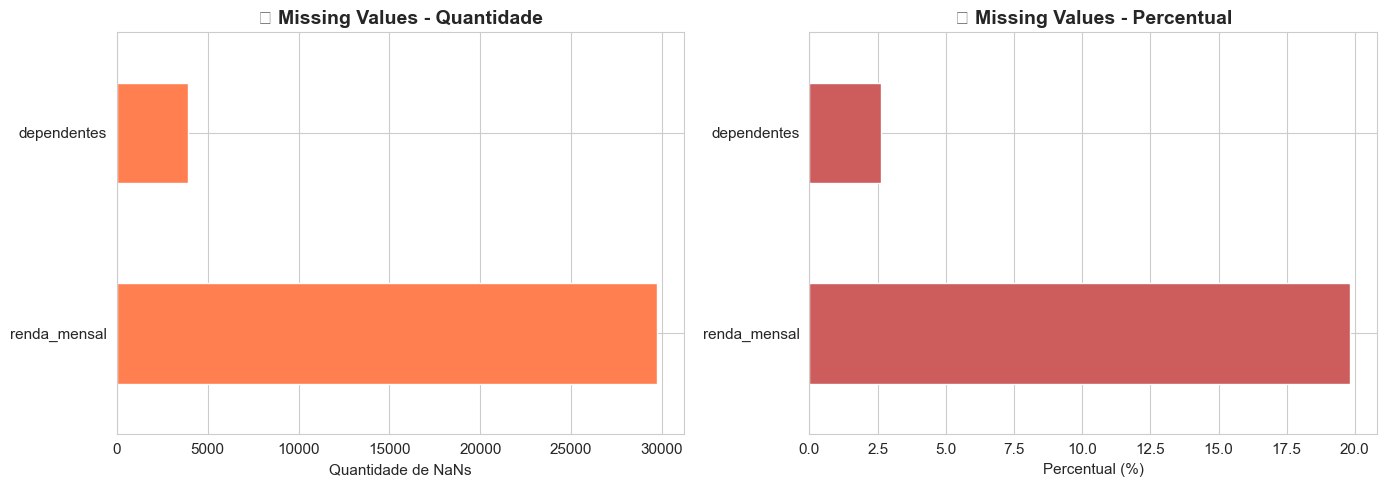


⚠️ Features com Missing Values:
              Quantidade  Percentual
renda_mensal       29731   19.820667
dependentes         3924    2.616000


In [7]:
# Missing values
missing = df_pt.isnull().sum()
missing_pct = (missing / len(df_pt)) * 100

missing_df = pd.DataFrame({
    'Quantidade': missing,
    'Percentual': missing_pct
}).sort_values('Quantidade', ascending=False)

# Plotar apenas com missing > 0
missing_df_plot = missing_df[missing_df['Quantidade'] > 0]

if len(missing_df_plot) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    missing_df_plot['Quantidade'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('📊 Missing Values - Quantidade', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Quantidade de NaNs')
    
    # Gráfico de percentual
    missing_df_plot['Percentual'].plot(kind='barh', ax=axes[1], color='indianred')
    axes[1].set_title('📊 Missing Values - Percentual', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Percentual (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️ Features com Missing Values:")
    print(missing_df_plot)
else:
    print("✅ Nenhum missing value!")

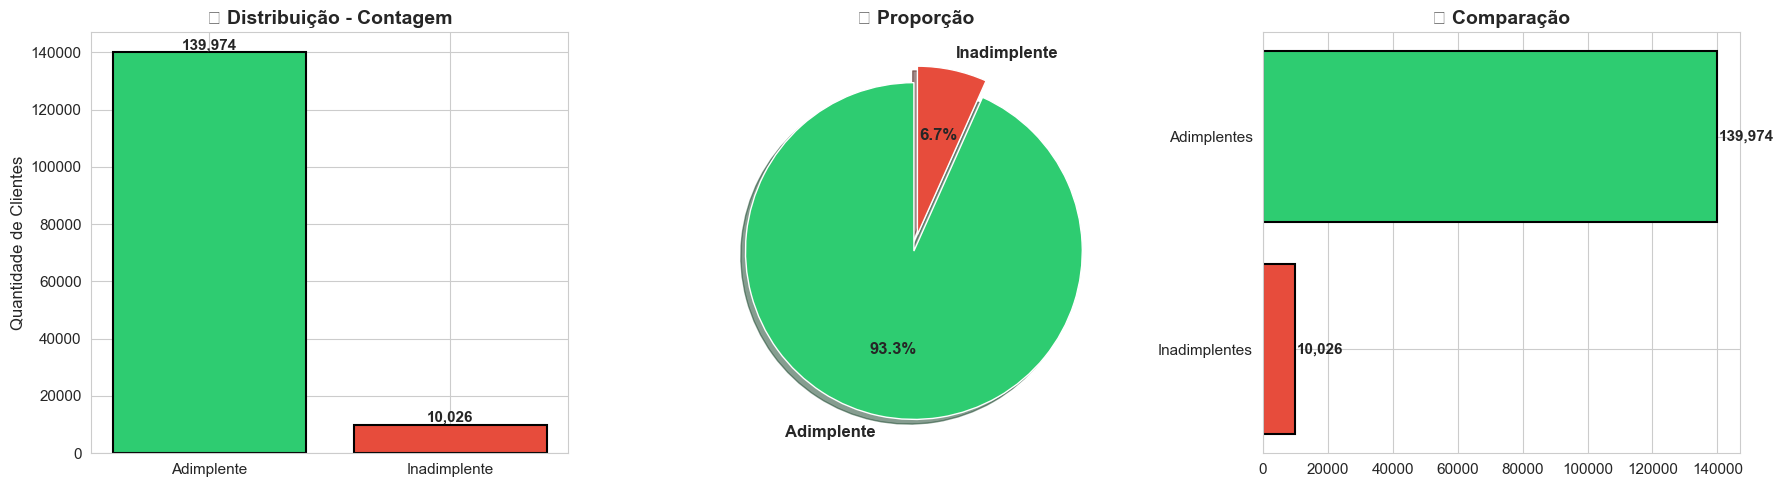


📊 ESTATÍSTICAS DA INADIMPLÊNCIA
✅ Total: 150,000
❌ Inadimplentes: 10,026 (6.68%)
✅ Adimplentes: 139,974 (93.32%)
⚖️ Razão: 1 inadimplente para cada 14.0 adimplentes


In [8]:
# Visualização da distribuição
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Contagem
counts = df_pt['inadimplente'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Adimplente', 'Inadimplente'], counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('📊 Distribuição - Contagem', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes', fontsize=12)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Gráfico 2: Pizza
explode = (0.05, 0.05)
axes[1].pie(counts.values, labels=['Adimplente', 'Inadimplente'], 
            autopct='%1.1f%%', colors=colors, explode=explode,
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('🥧 Proporção', fontsize=14, fontweight='bold')

# Gráfico 3: Comparação
inadimplentes = counts[1]
adimplentes = counts[0]
axes[2].barh(['Inadimplentes', 'Adimplentes'], [inadimplentes, adimplentes], 
             color=colors[::-1], edgecolor='black', linewidth=1.5)
axes[2].set_title('📊 Comparação', fontsize=14, fontweight='bold')
for i, v in enumerate([inadimplentes, adimplentes]):
    axes[2].text(v + 500, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas
print("\n" + "="*60)
print("📊 ESTATÍSTICAS DA INADIMPLÊNCIA")
print("="*60)
print(f"✅ Total: {len(df_pt):,}")
print(f"❌ Inadimplentes: {inadimplentes:,} ({inadimplentes/len(df_pt)*100:.2f}%)")
print(f"✅ Adimplentes: {adimplentes:,} ({adimplentes/len(df_pt)*100:.2f}%)")
print(f"⚖️ Razão: 1 inadimplente para cada {adimplentes/inadimplentes:.1f} adimplentes")
print("="*60)

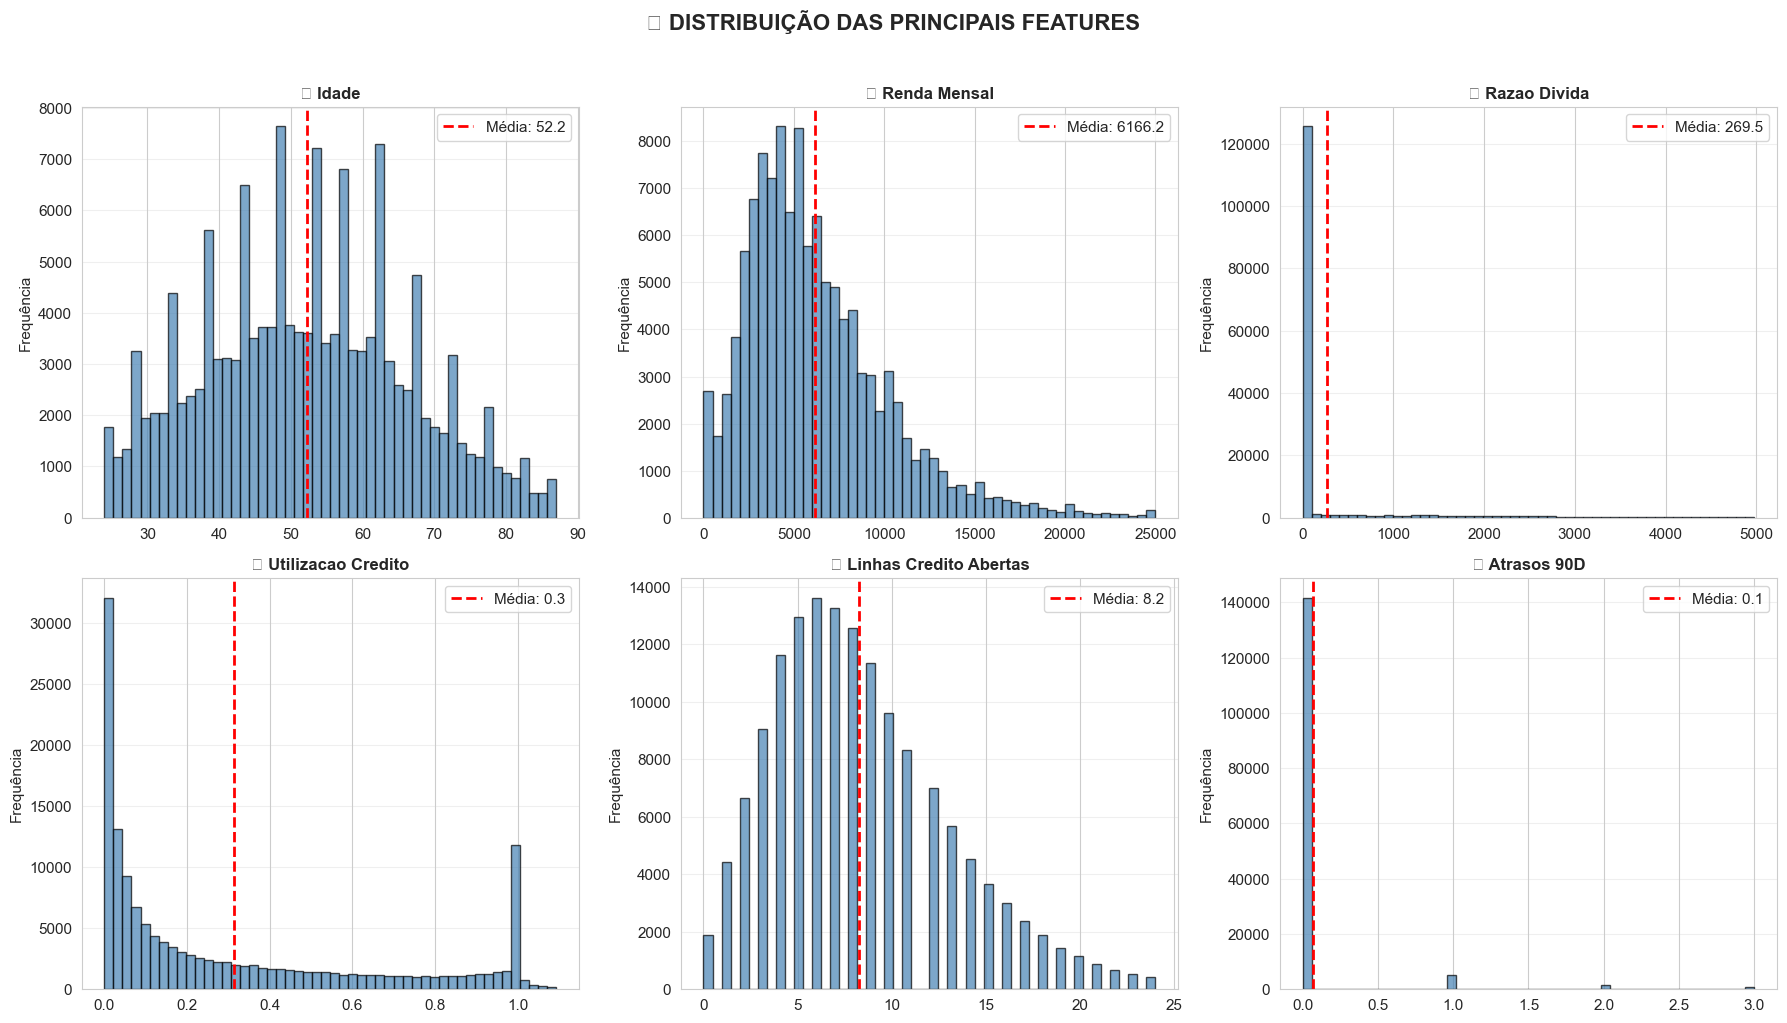

In [9]:
# Features principais
features_principais = ['idade', 'renda_mensal', 'razao_divida', 'utilizacao_credito',
                       'linhas_credito_abertas', 'atrasos_90d']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(features_principais):
    # Remover outliers extremos para visualização
    data = df_pt[col].dropna()
    q1, q99 = data.quantile([0.01, 0.99])
    data_plot = data[(data >= q1) & (data <= q99)]
    
    # Histograma
    axes[idx].hist(data_plot, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'📊 {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Linha de média
    mean_val = data_plot.mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                     label=f'Média: {mean_val:.1f}')
    axes[idx].legend()

plt.suptitle('📊 DISTRIBUIÇÃO DAS PRINCIPAIS FEATURES', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

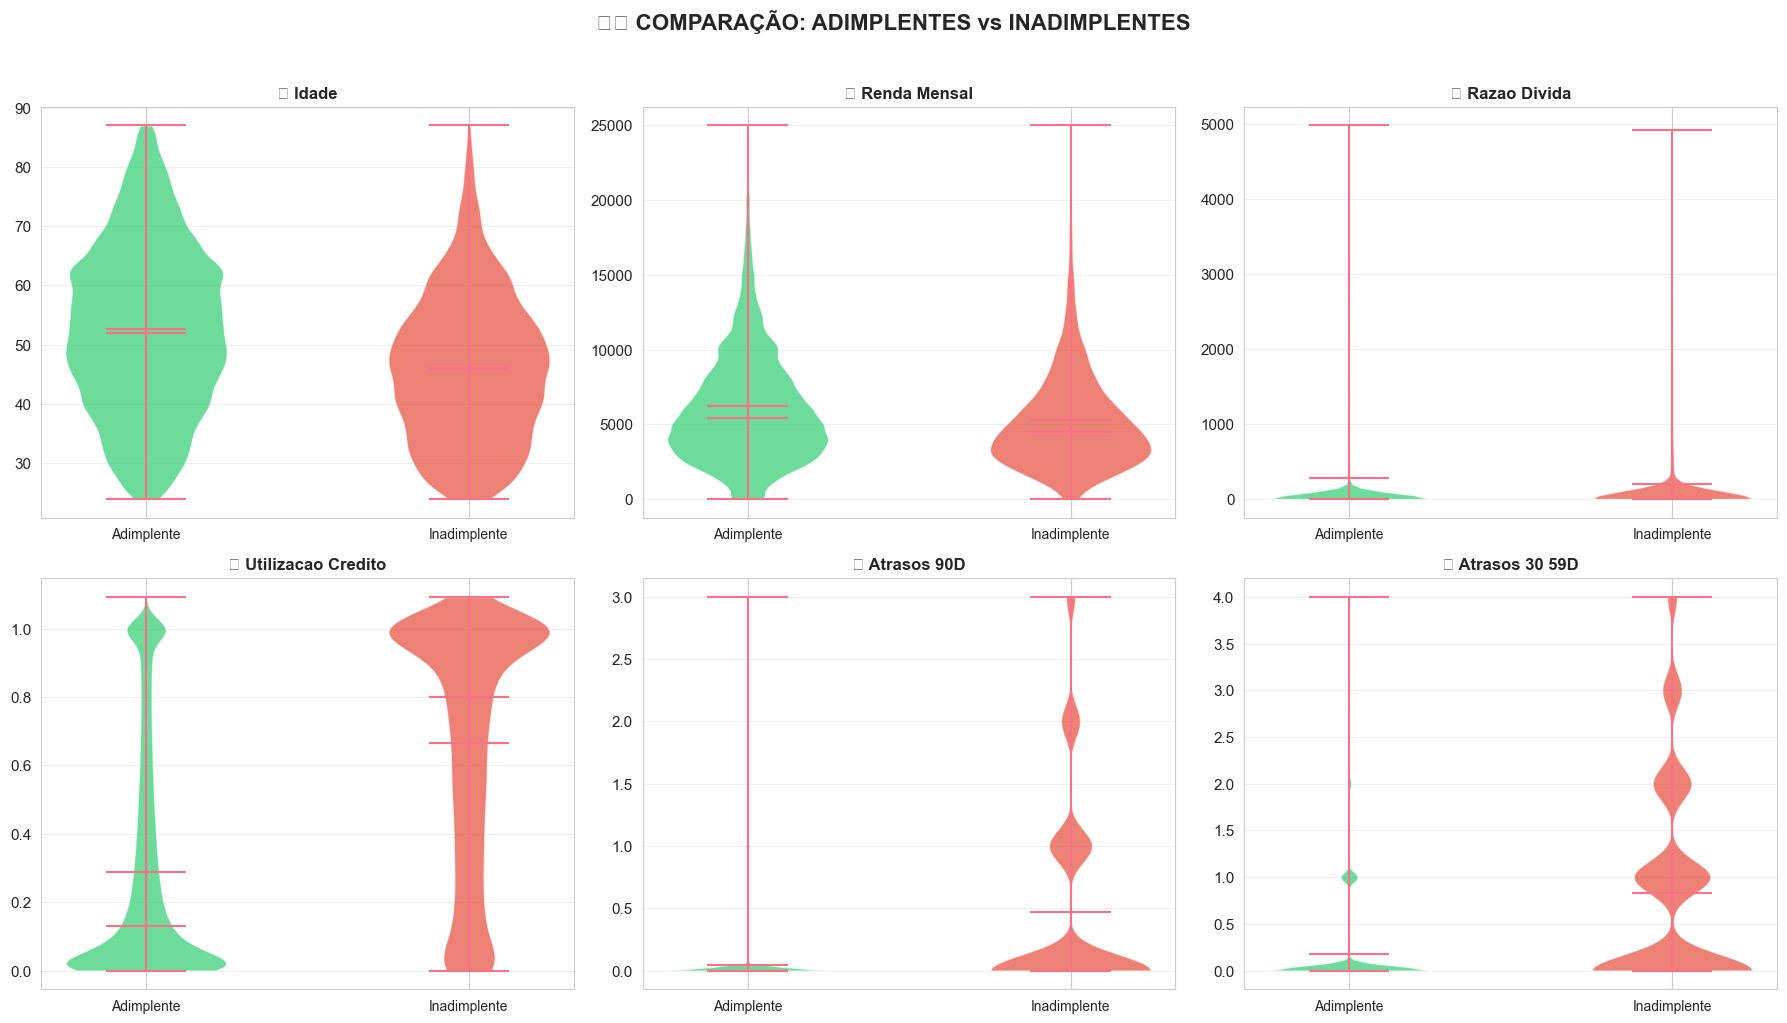

In [10]:
# Violin plots (mais bonitos que boxplots)
features_comparacao = ['idade', 'renda_mensal', 'razao_divida', 
                       'utilizacao_credito', 'atrasos_90d', 'atrasos_30_59d']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(features_comparacao):
    # Dados sem outliers
    data = df_pt[[col, 'inadimplente']].dropna()
    q1, q99 = data[col].quantile([0.01, 0.99])
    data_plot = data[(data[col] >= q1) & (data[col] <= q99)]
    
    # Violin plot
    parts = axes[idx].violinplot(
        [data_plot[data_plot['inadimplente']==0][col],
         data_plot[data_plot['inadimplente']==1][col]],
        positions=[0, 1],
        showmeans=True,
        showmedians=True
    )
    
    # Colorir
    colors = ['#2ecc71', '#e74c3c']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    axes[idx].set_title(f'🎻 {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Adimplente', 'Inadimplente'], fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('⚖️ COMPARAÇÃO: ADIMPLENTES vs INADIMPLENTES', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

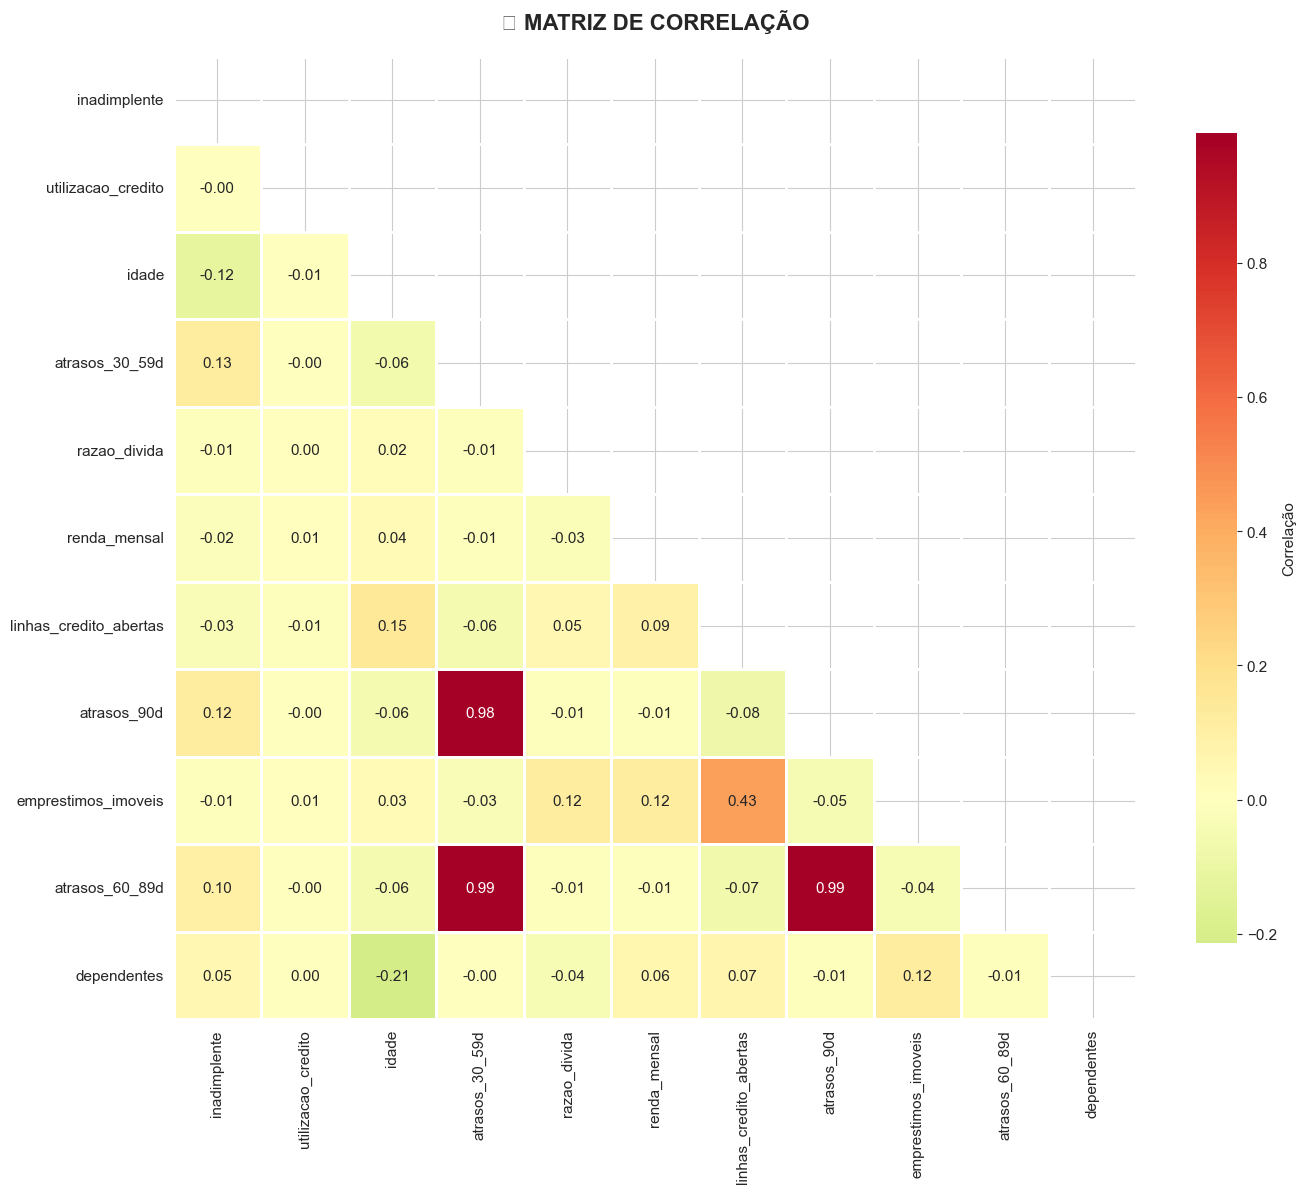

In [11]:
# Matriz de correlação
numeric_cols = df_pt.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 12))
correlation = df_pt[numeric_cols].corr()

# Máscara para triângulo superior
mask = np.triu(np.ones_like(correlation, dtype=bool))

# Heatmap
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlGn_r', center=0, square=True, linewidths=1,
            cbar_kws={'label': 'Correlação', 'shrink': 0.8})

plt.title('🔥 MATRIZ DE CORRELAÇÃO', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

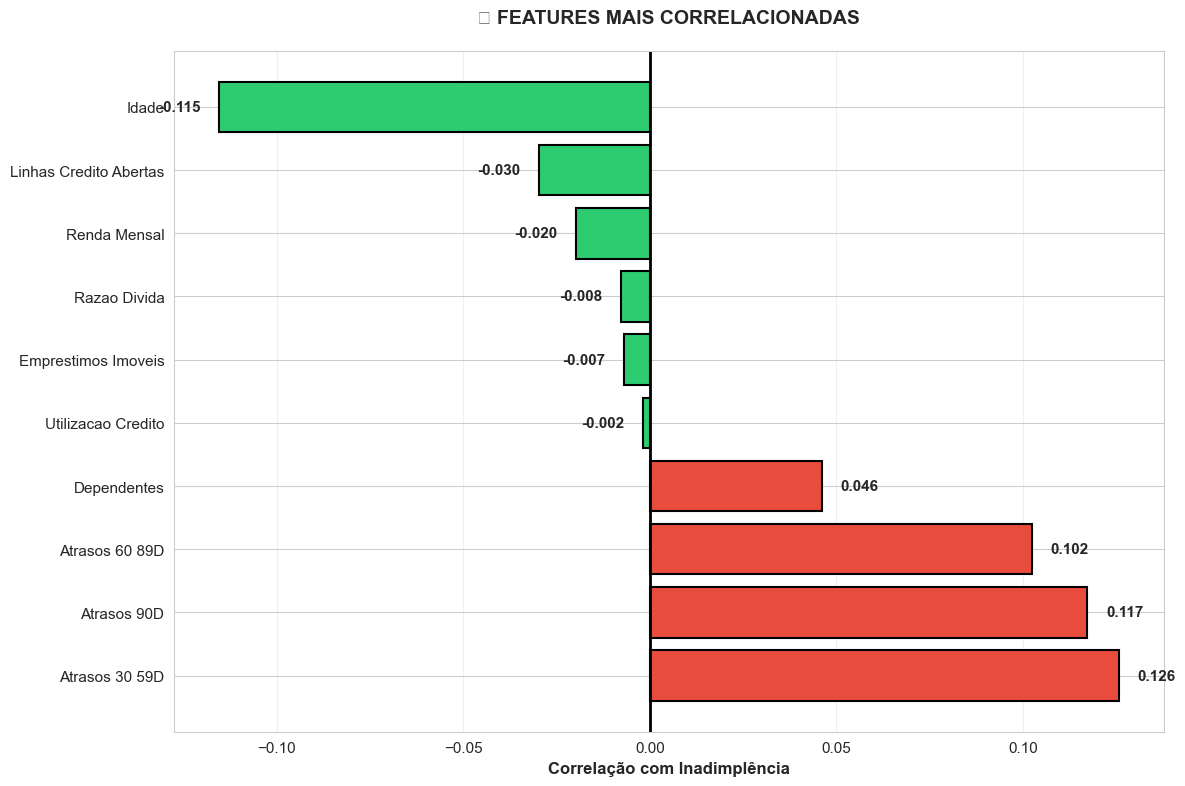


🏆 TOP 5 QUE AUMENTAM RISCO:
  Atrasos 30 59D............................... +0.1256
  Atrasos 90D.................................. +0.1172
  Atrasos 60 89D............................... +0.1023
  Dependentes.................................. +0.0460
  Utilizacao Credito........................... -0.0018

🛡️ TOP 5 QUE DIMINUEM RISCO:
  Emprestimos Imoveis.......................... -0.0070
  Razao Divida................................. -0.0076
  Renda Mensal................................. -0.0197
  Linhas Credito Abertas....................... -0.0297
  Idade........................................ -0.1154


In [12]:
# Correlação com target
corr_target = df_pt[numeric_cols].corrwith(df_pt['inadimplente']).sort_values(ascending=False)
corr_target = corr_target.drop('inadimplente')

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

colors_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_target]
bars = ax.barh(range(len(corr_target)), corr_target.values, color=colors_corr, 
               edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels([col.replace('_', ' ').title() for col in corr_target.index], fontsize=11)
ax.set_xlabel('Correlação com Inadimplência', fontsize=12, fontweight='bold')
ax.set_title('🎯 FEATURES MAIS CORRELACIONADAS', fontsize=14, fontweight='bold', pad=20)
ax.axvline(0, color='black', linewidth=2)
ax.grid(axis='x', alpha=0.3)

# Valores nas barras
for i, (idx, val) in enumerate(corr_target.items()):
    ax.text(val + 0.005 if val > 0 else val - 0.005, i, f'{val:.3f}', 
            va='center', ha='left' if val > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🏆 TOP 5 QUE AUMENTAM RISCO:")
print("="*60)
for feat, corr in corr_target.head(5).items():
    print(f"  {feat.replace('_', ' ').title():.<45} {corr:>+.4f}")

print("\n" + "="*60)
print("🛡️ TOP 5 QUE DIMINUEM RISCO:")
print("="*60)
for feat, corr in corr_target.tail(5).items():
    print(f"  {feat.replace('_', ' ').title():.<45} {corr:>+.4f}")

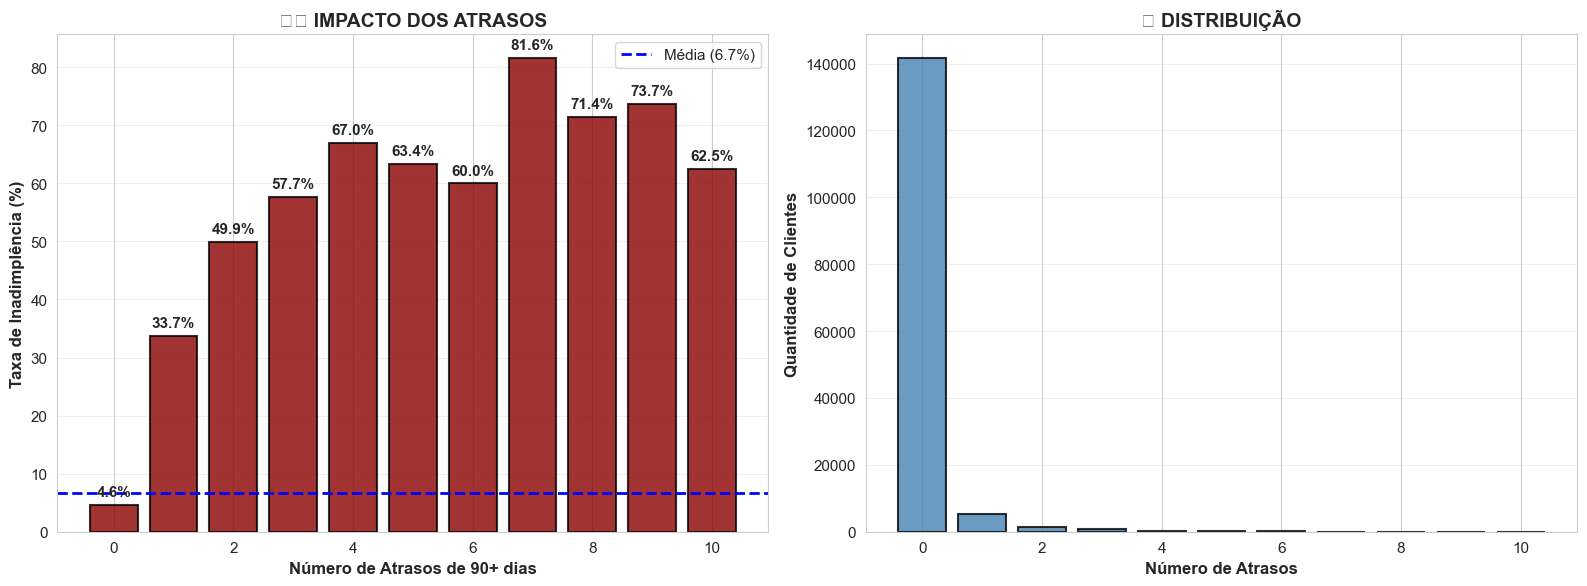


⚠️ ANÁLISE DE ATRASOS DE 90+ DIAS
📊 COM atraso: 8,338 (5.6%)
📊 SEM atraso: 141,662 (94.4%)
❌ Taxa COM atraso: 41.6%
✅ Taxa SEM atraso: 4.6%
🔥 Atrasos aumentam risco em 9.0x


In [13]:
# Taxa de inadimplência por atrasos de 90+ dias
late_analysis = df_pt.groupby('atrasos_90d')['inadimplente'].agg(['mean', 'count'])
late_analysis.columns = ['Taxa_Inadimplencia', 'Quantidade']
late_analysis['Taxa_Inadimplencia'] = late_analysis['Taxa_Inadimplencia'] * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taxa
x_pos = range(min(11, len(late_analysis)))
bars = axes[0].bar(x_pos, late_analysis.head(11)['Taxa_Inadimplencia'], 
                   color='darkred', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Número de Atrasos de 90+ dias', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Taxa de Inadimplência (%)', fontsize=12, fontweight='bold')
axes[0].set_title('⚠️ IMPACTO DOS ATRASOS', fontsize=14, fontweight='bold')
axes[0].axhline(df_pt['inadimplente'].mean()*100, color='blue', linestyle='--', 
               linewidth=2, label=f'Média ({df_pt["inadimplente"].mean()*100:.1f}%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Quantidade
axes[1].bar(x_pos, late_analysis.head(11)['Quantidade'], 
           color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Número de Atrasos', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantidade de Clientes', fontsize=12, fontweight='bold')
axes[1].set_title('📊 DISTRIBUIÇÃO', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
has_late = df_pt['atrasos_90d'] > 0
print("\n" + "="*70)
print("⚠️ ANÁLISE DE ATRASOS DE 90+ DIAS")
print("="*70)
print(f"📊 COM atraso: {has_late.sum():,} ({has_late.mean()*100:.1f}%)")
print(f"📊 SEM atraso: {(~has_late).sum():,} ({(~has_late).mean()*100:.1f}%)")
print(f"❌ Taxa COM atraso: {df_pt[has_late]['inadimplente'].mean()*100:.1f}%")
print(f"✅ Taxa SEM atraso: {df_pt[~has_late]['inadimplente'].mean()*100:.1f}%")
print(f"🔥 Atrasos aumentam risco em {df_pt[has_late]['inadimplente'].mean() / df_pt[~has_late]['inadimplente'].mean():.1f}x")
print("="*70)

In [14]:
print("\n" + "="*80)
print("🎯 PRINCIPAIS INSIGHTS - DATASET REAL")
print("="*80)

print("\n📊 1. VISÃO GERAL:")
print(f"   • Total: {len(df_pt):,} clientes")
print(f"   • Taxa inadimplência: {df_pt['inadimplente'].mean()*100:.2f}%")

print("\n🏆 2. FEATURES MAIS PREDITIVAS (Top 3):")
for i, (feat, corr) in enumerate(corr_target.head(3).items(), 1):
    print(f"   {i}. {feat.replace('_', ' ').title()}: {corr:+.4f}")

has_late = df_pt['atrasos_90d'] > 0
print("\n⚠️ 3. ATRASOS:")
print(f"   • Taxa COM atraso: {df_pt[has_late]['inadimplente'].mean()*100:.1f}%")
print(f"   • Taxa SEM atraso: {df_pt[~has_late]['inadimplente'].mean()*100:.1f}%")
print(f"   • 🔥 Aumento do risco: {df_pt[has_late]['inadimplente'].mean() / df_pt[~has_late]['inadimplente'].mean():.1f}x")

print("\n💡 CONCLUSÃO:")
print("   Atrasos de 90+ dias é o MELHOR preditor de inadimplência!")
print("="*80)


🎯 PRINCIPAIS INSIGHTS - DATASET REAL

📊 1. VISÃO GERAL:
   • Total: 150,000 clientes
   • Taxa inadimplência: 6.68%

🏆 2. FEATURES MAIS PREDITIVAS (Top 3):
   1. Atrasos 30 59D: +0.1256
   2. Atrasos 90D: +0.1172
   3. Atrasos 60 89D: +0.1023

⚠️ 3. ATRASOS:
   • Taxa COM atraso: 41.6%
   • Taxa SEM atraso: 4.6%
   • 🔥 Aumento do risco: 9.0x

💡 CONCLUSÃO:
   Atrasos de 90+ dias é o MELHOR preditor de inadimplência!
